In [41]:
"""Imports"""
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
import os
print(os.getcwd())

/scratch/dzc5938


In [43]:
"""Constants"""
### pre measurement on 07/18
# TANK_RADIUS_1T_mm = 525.78
# BOTTOM_PADDLE_1_CENTER = (-175, 325, -1228.05)
# BOTTOM_PADDLE_2_CENTER = (-43.18, 185.42, -1228.05)
# BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
# TOP_PADDLE_CENTER = (86,86,766.5)

### post measurement on 07/18
TANK_RADIUS_1T_mm = 525.78
BOTTOM_PADDLE_1_CENTER = (-31.75, 69.85, -1228.05)
BOTTOM_PADDLE_2_CENTER = (25.4, 177.8, -1228.05)
BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
TOP_PADDLE_CENTER = (146.05, 139.7, 766.5)


###
BPs_list = ["lol",BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER]
###

# for reco simulation
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

In [44]:
"""Functions"""
def find_intersection_with_z(reco_entry_xy, reco_exit_xy, z_entry, z_exit, target_z):
    """
    Extends a vector defined by two points (reco entry and exit) and finds its intersection
    with a given z-plane.

    Parameters:
        reco_entry_xy (tuple): (x, y) coordinates of the reconstructed entry point
        reco_exit_xy (tuple): (x, y) coordinates of the reconstructed exit point
        z_entry (float): z-coordinate of reco entry point (usually TANK_TOP_Z_mm)
        z_exit (float): z-coordinate of reco exit point (usually TANK_BOTTOM_Z_mm)
        target_z (float): the z-plane you want to intersect with (e.g. 766.5 or -1228.05)

    Returns:
        (x, y, target_z): the 3D point where the line intersects the target_z plane
    """
    p0 = np.array([reco_entry_xy[0], reco_entry_xy[1], z_entry], dtype=float)
    p1 = np.array([reco_exit_xy[0], reco_exit_xy[1], z_exit], dtype=float)
    direction = p1 - p0

    if direction[2] == 0:
        raise ValueError("Vector is parallel to the z-plane; no intersection.")

    t = (target_z - p0[2]) / direction[2]
    intersection = p0 + t * direction
    return tuple(intersection)

def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data['reco_events'], data['all_bottom_paddle_tags_for_phase']

def calc_radius(x, y):
    """Simple stuff"""
    return (x**2 + y**2)**0.5

# def get_delta_radius(recos, BP_tags, entry_or_exit: str) -> list[float]:
#     delta_radius_list = []
#     num_events = len(recos)
#     for i in range(num_events):
#         # Get which BP was tagged
#         if BP_tags[i] == 1:
#             BP_loc = BOTTOM_PADDLE_1_CENTER
#         elif BP_tags[i] == 2:
#             BP_loc = BOTTOM_PADDLE_2_CENTER
#         elif BP_tags[i] == 3:
# #             BP_loc = BOTTOM_PADDLE_MIDPOINT
#             continue
# #             print("midpoint!")
# #         if not throughgoing(recos[i]):
# #             continue
#         if entry_or_exit == "entry":
#             reco_x = recos[i]["reco"][0]
#             reco_y = recos[i]["reco"][1]
#             true_x = TOP_PADDLE_CENTER[0]
#             true_y = TOP_PADDLE_CENTER[1]
#         elif entry_or_exit == "exit":
#             reco_x = recos[i]["reco"][2]
#             reco_y = recos[i]["reco"][3]
#             true_x = BP_loc[0]
#             true_y = BP_loc[1]
#         reco_r = calc_radius(reco_x, reco_y)
#         true_r = calc_radius(true_x, true_y)
#         if reco_r > 520: continue # tried to fix big peak at 404
# #         if calc_radius(recos[i]["reco"][0], recos[i]["reco"][1]) > 500: continue
#         delta_radius_list.append(np.abs(reco_r - true_r))
#     return delta_radius_list

def get_delta_radius(recos, BP_tags, entry_or_exit: str, pref_BP) -> list[float]:
    delta_radius_list = []
    num_events = len(recos)
    for i in range(num_events):
        if BP_tags[i] != pref_BP:
            continue
        if pref_BP == 1:
            BP_loc = BOTTOM_PADDLE_1_CENTER
        elif pref_BP == 2:
            BP_loc = BOTTOM_PADDLE_2_CENTER

        entry_reco_x = recos[i]["reco"][0]
        entry_reco_y = recos[i]["reco"][1]
        entry_true_x = TOP_PADDLE_CENTER[0]
        entry_true_y = TOP_PADDLE_CENTER[1]

        exit_reco_x = recos[i]["reco"][2]
        exit_reco_y = recos[i]["reco"][3]
        exit_true_x = BP_loc[0]
        exit_true_y = BP_loc[1]
        
        # attempted fix by moving this line. therefore, if it's a bad reco on sim tank size,
        # we skip
#         reco_r = calc_radius(reco_x, reco_y)
#         if reco_r > 520:
#             continue # tried to fix big peak at 404
#         print(calc_radius(entry_reco_x, entry_reco_y))
        if calc_radius(entry_reco_x, entry_reco_y) > 520 or calc_radius(exit_reco_x, exit_reco_y) > 520:
            continue

        top_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TOP_PADDLE_CENTER[2])
        bot_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, BP_loc[2])

        if entry_or_exit == "entry":
            reco_x, reco_y, reco_z = top_intsec
            true_x, true_y = entry_true_x, entry_true_y
        elif entry_or_exit == "exit":
            reco_x, reco_y, reco_z = bot_intsec
            true_x, true_y = exit_true_x, exit_true_y

#         reco_r = calc_radius(reco_x, reco_y)
#         true_r = calc_radius(true_x, true_y)
# #         if reco_r > 520:
# #             continue # tried to fix big peak at 404
# #         if np.abs(reco_r - true_r) > 100:
# #             print(reco_x, reco_y)
#         delta_radius_list.append(np.abs(reco_r - true_r))
        num_hits = recos[i]["total_charge"][1]
        delta_radius_list.append([reco_x, reco_y, num_hits, np.sqrt((reco_x - true_x)**2 + (reco_y - true_y)**2)])
    return delta_radius_list

def get_cos_theta(recos) -> list[float]:
    cos_theta_list = []
    num_events = len(recos)
    for i in range(num_events):
        # Get which BP was tagged
        if BP_tags[i] == 1:
#             continue
            BP_loc = BOTTOM_PADDLE_1_CENTER
        elif BP_tags[i] == 2:
            continue
#             BP_loc = BOTTOM_PADDLE_2_CENTER
        elif BP_tags[i] == 3:
            continue
#             BP_loc = BOTTOM_PADDLE_MIDPOINT
#         if not throughgoing(recos[i]):
#             continue
        reco_x_entry = recos[i]["reco"][0]
        reco_y_entry = recos[i]["reco"][1]
        reco_x_exit = recos[i]["reco"][2]
        reco_y_exit = recos[i]["reco"][3]

        true_x_entry = TOP_PADDLE_CENTER[0]
        true_y_entry = TOP_PADDLE_CENTER[1]
        true_z_entry = TOP_PADDLE_CENTER[2]

        true_x_exit = BP_loc[0]
        true_y_exit = BP_loc[1]
        true_z_exit = BP_loc[2]
        

        true_vec = np.array([true_x_exit, true_y_exit, true_z_exit]) - np.array([true_x_entry, true_y_entry, true_z_entry])
        reco_vec = np.array([reco_x_exit, reco_y_exit, TANK_BOTTOM_Z_mm]) - np.array([reco_x_entry, reco_y_entry, TANK_TOP_Z_mm])

        true_normalized = true_vec / np.linalg.norm(true_vec)
        reco_normalized = reco_vec / np.linalg.norm(reco_vec)
        
        dot_product = np.dot(true_normalized, reco_normalized)
        cos_theta_list.append(dot_product)
#         if dot_product < 0:
#             print(reco_x_entry, reco_y_entry, true_x_entry, true_y_entry, reco_x_exit, reco_y_exit, true_x_exit, true_y_exit)
    return cos_theta_list

def majority_trigger(event) -> bool:
    """Index into the 26th hit. If it is one of the 28 bottom PMTs, we know
    this is a majority trigger event."""
    pmt_num = event["hits"][25][4]
    if pmt_num <= 28:
        return True
    return False

def throughgoing(event) -> bool:
    """Returns a bool if reco points are within top and bottom bases of 
    cylindrical detector, because this implies they did not enter/exit side"""
    reco_x_entry = event["reco"][0]
    reco_y_entry = event["reco"][1]
    reco_x_exit = event["reco"][2]
    reco_y_exit = event["reco"][3]
    if (calc_radius(reco_x_entry, reco_y_entry) < TANK_RADIUS_1T_mm) and (calc_radius(reco_x_exit, reco_y_exit) < TANK_RADIUS_1T_mm):
        return True
    return False

In [45]:
user_file_choice = 5

##### water
### eloss files
elosstank_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_all/07_16_25_disk_d_phase_3_weight_1_reco_elosstank_digit_weight_all.pkl"
elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_all/07_23_25_disk_d_phase_3_cfd_1_reco_elosstank_digit_edge_all.pkl"
elosstank_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_per/07_16_25_disk_d_phase_3_weight_1_reco_elosstank_digit_weight_per.pkl"
elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_per/07_16_25_disk_d_phase_3_cfd_1_reco_elosstank_digit_edge_per.pkl"

### numCher files
numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_all/07_23_25_disk_d_phase_3_cfd_1_reco_numCher_digit_edge_all.pkl"
numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_per/07_23_25_disk_d_phase_3_cfd_1_reco_numCher_digit_edge_per.pkl"
numCher_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_all/07_16_25_disk_d_phase_3_weight_1_reco_numCher_digit_weight_all.pkl"
numCher_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/07_23_25_disk_d_phase_3_weight_test_reco_numCher_digit_weight_per.pkl"

water_file_list = [
    elosstank_digit_weight_all,  #0
    elosstank_digit_edge_all,    #1
    elosstank_digit_weight_per,  #2
    elosstank_digit_edge_per,    #3
    numCher_digit_edge_all,      #4
    numCher_digit_edge_per,      #5
    numCher_digit_weight_all,    #6
    numCher_digit_weight_per     #7
]
##### wbls
### only edge, weighted got messed up
wbls_elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_all/07_16_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_all.pkl"
wbls_elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_per/07_16_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_per.pkl"
wbls_numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_all/07_16_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_all.pkl"
wbls_numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_per/07_16_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_per.pkl"

wbls_file_list = [
    wbls_elosstank_digit_edge_all, #0
    wbls_elosstank_digit_edge_per, #1
    wbls_numCher_digit_edge_all,   #2
    wbls_numCher_digit_edge_per    #3
]

real_file = water_file_list[user_file_choice]
###
reco_events, BP_tags = load_data(real_file)
# reco_type = real_file.split("/")[8]
reco_type = real_file.split("/")[10]
hist_tag = str(reco_type)
print("total number of recos", len(reco_events))
print(hist_tag)
# print(reco_events[0]['total_charge']) # proof im not crazy
print(len(BP_tags))

total number of recos 1973
numCher_digit_edge_per
1973


In [46]:
# values = get_delta_radius(reco_events, BP_tags, "entry", pref_BP)
# print("len values", len(values))

In [47]:
# # Split into two columns
# ent_or_ex = "entry"
# BP_choice = 2
# values = get_delta_radius(reco_events, BP_tags, ent_or_ex, BP_choice)
# col1 = [x[0] for x in values] # x
# col2 = [x[1] for x in values] # y
# nhits_list = [x[2] for x in values] # hits

# scatter = plt.scatter(col1, col2, alpha=0.5, s=10, c=nhits_list)
# plt.scatter(BPs_list[BP_choice][0], BPs_list[BP_choice][1], color='red', s=20, label=f'BP {BP_choice} loc', zorder=5)
# plt.title(f'Only BP {BP_choice} {ent_or_ex}s')

# # Add green circle at r = 525.78
# circle = plt.Circle((0, 0), 525.78, color='green', fill=False, linewidth=1.5, linestyle='--', label='r = 525.78')
# plt.gca().add_patch(circle)

# # Set fixed axis scale
# plt.axis('equal')  # Ensures the aspect ratio is 1:1
# # plt.xlim(-600, 600)  # Customize as needed
# # plt.ylim(-600, 600)

# # Add color bar
# cbar = plt.colorbar(scatter)
# cbar.set_label('nhits')  # You can change this label

# plt.xlabel('x')
# plt.ylabel('y')
# plt.legend()
# plt.tight_layout()
# plt.show()

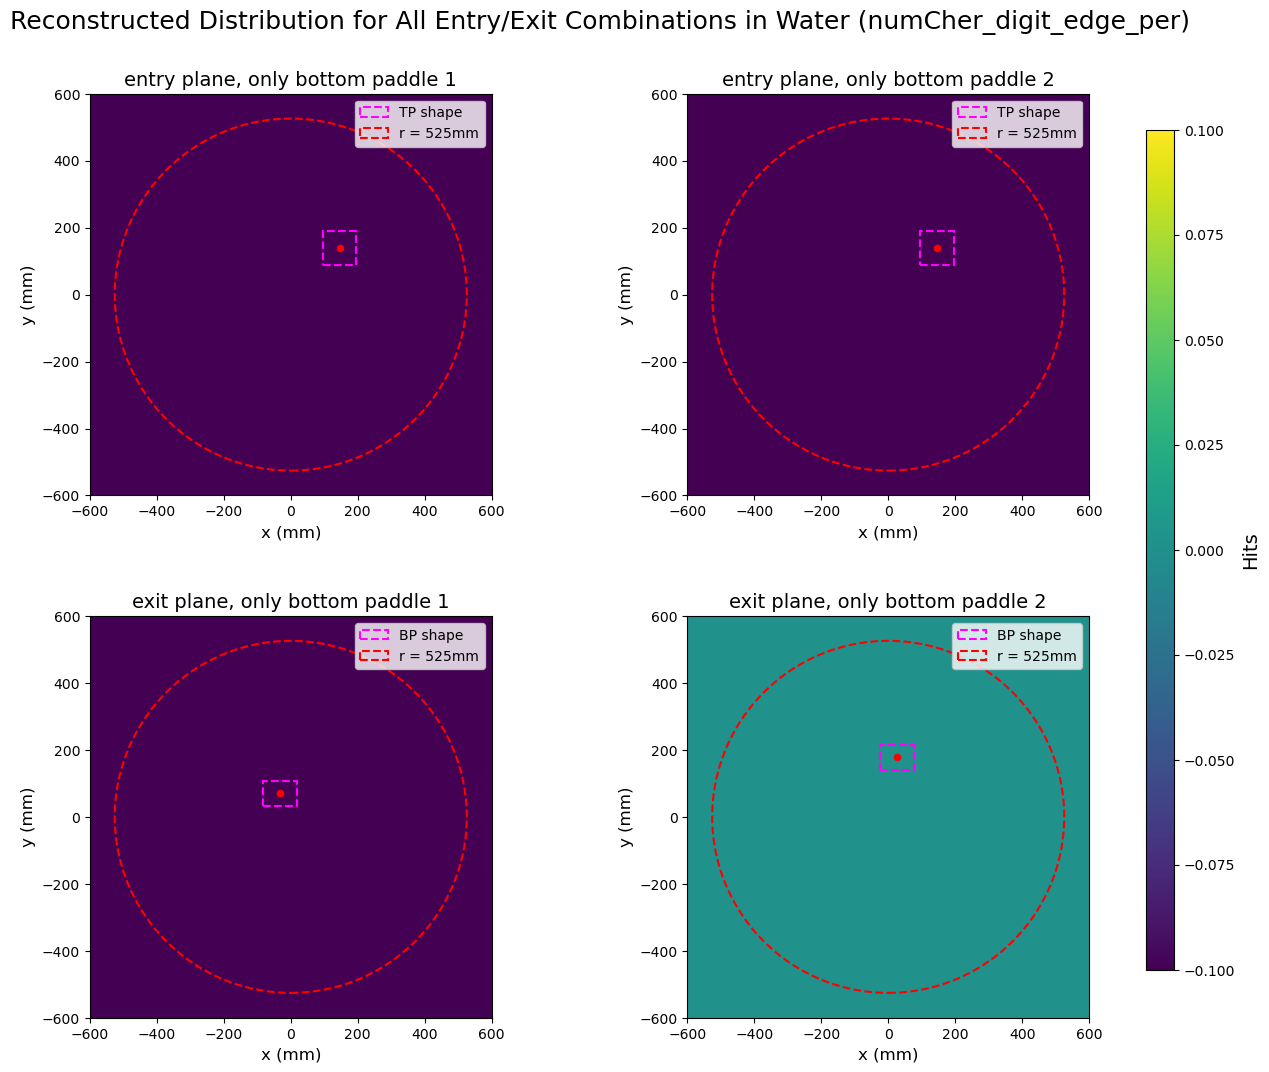

In [48]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

combinations = [["entry", 1], ["entry", 2], ["exit", 1], ["exit", 2]]
data_combinations = []

###
for i in combinations:
    e_type = i[0]
    BP_type = i[1]
    values = get_delta_radius(reco_events, BP_tags, e_type, BP_type) # doesn't actually do delta_radius
    col1 = [x[0] for x in values]  # x
    col2 = [x[1] for x in values]  # y
    nhits_list = [x[2] for x in values]  # color (nhits)
    data_combinations.append((col1, col2, e_type, BP_type, nhits_list))
###

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f"Reconstructed Distribution for All Entry/Exit Combinations in Water ({hist_tag})", fontsize=18, x=0.51, y=0.95)

# Loop through each subplot and draw the same scatter plot
combo = 0
for ax in axes.flat:
    col1, col2, ent_or_ex, BP_choice, nhits_list = data_combinations[combo]
#     scatter = ax.scatter(col1, col2, alpha=0.5, s=10, c=nhits_list, cmap='viridis')
#     hist = ax.hist2d(col1, col2, bins=50, cmap='viridis')
###
    hist = ax.hist2d(
        col1,
        col2,
        bins=50,
        range=[[-600, 600], [-600, 600]],
        cmap='viridis',
        norm=mcolors.Normalize(vmin=0)  # Ensure 0 is mapped to the lowest color
    )
###

    if ent_or_ex == "entry":
        ax.scatter(TOP_PADDLE_CENTER[0], TOP_PADDLE_CENTER[1], color='red', s=20,
               zorder=5) # label=f'TOP_PADDLE loc', 
        
        # center and size
        center_x, center_y = TOP_PADDLE_CENTER[0], TOP_PADDLE_CENTER[1]
        width, height = 100, 100

        # Compute bottom-left corner
        bottom_left_x = center_x - width / 2
        bottom_left_y = center_y - height / 2

        # Create rectangle
        rect = plt.Rectangle(
            (bottom_left_x, bottom_left_y),
            width,
            height,
            linewidth=1.5,
            edgecolor='magenta',
            facecolor='none',
            linestyle='--',
            label='TP shape'
        )
        ax.add_patch(rect)
        
    elif ent_or_ex == "exit":
        ax.scatter(BPs_list[BP_choice][0], BPs_list[BP_choice][1], color='red', s=20,
                   zorder=5) # label=f'BP {BP_choice} loc', 
        if BP_choice == 1:
            center_x, center_y = BOTTOM_PADDLE_1_CENTER[0], BOTTOM_PADDLE_1_CENTER[1]
        elif BP_choice == 2:
            center_x, center_y = BOTTOM_PADDLE_2_CENTER[0], BOTTOM_PADDLE_2_CENTER[1]
        width, height = (4*25.4), (3*25.4)
        bottom_left_x = center_x - width / 2
        bottom_left_y = center_y - height / 2
        rect = plt.Rectangle(
            (bottom_left_x, bottom_left_y),
            width,
            height,
            linewidth=1.5,
            edgecolor='magenta',
            facecolor='none',
            linestyle='--',
            label='BP shape'
        )
        ax.add_patch(rect)
        
    
#     ax.scatter(0, 0, color='red', s=20, marker='*',
#             zorder=5) # label=f'origin',

    # Add green circle at r = 525.78
    circle = plt.Circle((0, 0), 525.78, color='red', fill=False, linewidth=1.5,
                        linestyle='--', label='r = 525mm')
    ax.add_patch(circle)

    ax.set_aspect('equal')
    ax.set_xlim(-600, 600)
    ax.set_ylim(-600, 600)
    ax.set_xlabel('x (mm)', fontsize=12)
    ax.set_ylabel('y (mm)', fontsize=12)
    ax.legend(loc='upper right')
    ax.set_title(f'{ent_or_ex} plane, only bottom paddle {BP_choice}', fontsize=14)
    
    combo += 1

# Adjust layout to make space for the colorbar
fig.subplots_adjust(right=0.88, wspace=0.3, hspace=0.3)

# Add one large colorbar to the right of all subplots
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
# cbar = fig.colorbar(scatter, cax=cbar_ax)
# cbar.set_label('nhits')
cbar = fig.colorbar(hist[3], cax=cbar_ax)
cbar.set_label("Hits", fontsize=14)
# cbar = fig.colorbar(img, cax=cbar_ax)

plt.show()
# plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/wbls1pcnt_{hist_tag}.png", dpi=300, bbox_inches="tight")